# Homework 6  - Logistic Regression without using any libraries. 

## Your Name Here

Student Name: Lily Nguyen

Student UT EID: lmn934

---

Name: John "Jack" Mayberry

EID: jmm23398

---

Date Created: Saturday, July 4, 2025

Date Last Modified: July 16, 2025

---

Totoal Points 20. 



In [3935]:
# Standard Headers
# You are welcome to add additional headers here if you wish
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Enable inline mode for matplotlib so that Jupyter displays graphs
%matplotlib inline

# Your allowed to use only the above libraries that are imported. No other libs should be used in this assignment. 

## Heart Dataset 

In this Assignment we will work with some patients dataset. 

We have access to 303 patients data. The features are listed below. 

In [3936]:
# Your code here
heart_df = pd.read_csv("Heart.csv")
heart_df

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,Target
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,typical,110,264,0,0,132,0,1.2,2,0.0,reversable,Yes
299,68,1,asymptomatic,144,193,1,0,141,0,3.4,2,2.0,reversable,Yes
300,57,1,asymptomatic,130,131,0,0,115,1,1.2,2,1.0,reversable,Yes
301,57,0,nontypical,130,236,0,2,174,0,0.0,2,1.0,normal,Yes


In [3937]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        303 non-null    int64  
 1   Sex        303 non-null    int64  
 2   ChestPain  303 non-null    object 
 3   RestBP     303 non-null    int64  
 4   Chol       303 non-null    int64  
 5   Fbs        303 non-null    int64  
 6   RestECG    303 non-null    int64  
 7   MaxHR      303 non-null    int64  
 8   ExAng      303 non-null    int64  
 9   Oldpeak    303 non-null    float64
 10  Slope      303 non-null    int64  
 11  Ca         299 non-null    float64
 12  Thal       301 non-null    object 
 13  Target     303 non-null    object 
dtypes: float64(2), int64(9), object(3)
memory usage: 33.3+ KB


**Age:** The person’s age in years

**Sex:** The person’s sex (1 = male, 0 = female)

**ChestPain:** chest pain type

* Value 0: asymptomatic
* Value 1: atypical angina
* Value 2: non-anginal pain
* Value 3: typical angina

**RestBP:** The person’s resting blood pressure (mm Hg on admission to the hospital)

**Chol:** The person’s cholesterol measurement in mg/dl

**Fbs:** The person’s fasting blood sugar (> 120 mg/dl, 1 = true; 0 = false)
restecg: resting electrocardiographic results

* Value 0: showing probable or definite left ventricular hypertrophy by Estes’ criteria
* Value 1: normal
* Value 2: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)

**RestECG:** The person’s maximum heart rate achieved

**MaxHR:** Exercise induced angina (1 = yes; 0 = no)

**Oldpeak:** ST depression induced by exercise relative to rest (‘ST’ relates to positions on the ECG plot. See more here)

**Slope:** the slope of the peak exercise ST segment — 0: downsloping; 1: flat; 2: upsloping

* 0: downsloping; 
* 1: flat; 
* 2: upsloping

**Ca:** The number of major vessels (0–3)

**Thal:** A blood disorder called thalassemia Value 0: NULL (dropped from the dataset previously

* Value 1: fixed defect (no blood flow in some part of the heart)
* Value 2: normal blood flow
* Value 3: reversible defect (a blood flow is observed but it is not normal)

**Target:** Heart disease (1 = no, 0= yes)

# Task 1 - (4 points)
We want to use logistic regerssion to predict if a patient will have heart problems or not. The column "Target" in our datasets includes data about heart disease. If the patient had heart disease, the patient's "Target" value equals 1. Otherwise, "Target" equals 0.

Prepare your data set for predicting heart disease ("Target" column) by using 3 features:

* Age of the patient (Column **"Age"**)
* Gender of the patient (male or female - Column **"Sex"**)
* Cholestrol level of the patient (Column **"Chol"**) 

Split your data into 80% traning data and 20% test data ***without*** using any libraries other than the ones imported above. You must do it manually.

* Do a maximum of **100 iterations**
* Use a very small learning rate for checking your GD implementation. 
* Your are allowed to use your choice of learning rate, like using 0.0001, 0.001 or 0.01 or 0.1 or higher/lower. 
* **Visualize your error/costs over the iterations with a plot**.
* No need to add an y-intercept in this task. 

(**4 points** - 3 points for code, 1 point for cost visualization)

In [3938]:
# logistic regression without intercept term -> predict heart problems yes/no

# change 'Target' col values to binary outcomes '0' or '1' (ints)
heart_df['Target'] = heart_df['Target'].map({'Yes': 1, 'No': 0})

# manual 80/20 train-test split
shuffled_df = heart_df.sample(frac=1, random_state=42).reset_index(drop=True)
train_size = int(0.8 * len(shuffled_df))

train_set = shuffled_df[:train_size]
test_set = shuffled_df[train_size:]

# features and target
features = ['Age', 'Sex', 'Chol']
target = 'Target' # 1 = has disease, 0 = no disease

# split dataset to train-test subsets, convert to numpy array to use with assignment's packages
X_train = train_set[features].to_numpy()
X_test = test_set[features].to_numpy()
y_train = train_set[target].to_numpy()
y_test = test_set[target].to_numpy()

# standardizing X_train and X_test data since variables are scaled differently
# -> make data have mean=0, stddev=1
X_train = (X_train - X_train.mean(axis=0)) / X_train.std(axis=0)
X_test = (X_test - X_test.mean(axis=0)) / X_test.std(axis=0)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
print(f'Train %: {X_train.shape[0]/(X_train.shape[0]+X_test.shape[0]):.0%}')
print(f'Test %: {X_test.shape[0]/(X_train.shape[0]+X_test.shape[0]):.0%}')


(242, 3)
(61, 3)
(242,)
(61,)
Train %: 80%
Test %: 20%


Now, we run the logistic regression model without sklearn packages.

In [3939]:
def sigmoid(z):
    '''
    convert continous value into range of 0 to 1 (sigmoid = S-curve)
    sigmoid(z) = P(y=1|X)
    where z = β_0{hat} + β_1{hat}*x_1 + β_2{hat}*x_2 + ... + β_k{hat}*x_k
    '''
    return 1 / (1 + np.exp(-z))

def cost_function(X, y, weights):
    '''
    compute cost for logistic regression
    '''
    m, n = X.shape
    x_dot_weights = X.dot(weights)

    # use np.clip on all log(0) values to prevent undefined-ness
    y_pred = sigmoid(x_dot_weights)
    y_pred = np.clip(y_pred, 1e-10, 1 - 1e-10)

    cost = 1.0 / m * (-y.T.dot(np.log(y_pred)) - (1 - y).T.dot(np.log(1 - y_pred)))

    return cost

def gradient(X, y, weights):
    '''
    compute gradient for logistic regression
    '''
    m, n = X.shape
    x_dot_weights = X.dot(weights)
    
    grad = (1.0 / m) * X.T.dot(sigmoid(x_dot_weights) - y)

    return grad

In [3940]:
# use gradient descent -> optimization
num_iters = 100
learning_rate = 0.1

cost_list = []
weights = np.zeros(X_train.shape[1])

for i in range(num_iters):

    cost = cost_function(X_train, y_train, weights)
    print(f'Cost for iteration {i + 1}: {cost}')
    cost_list.append(cost)

    grad = gradient(X_train, y_train, weights)
    weights = weights - learning_rate * grad

Cost for iteration 1: 0.6931471805599452
Cost for iteration 2: 0.6902458926342222
Cost for iteration 3: 0.68747296273709
Cost for iteration 4: 0.684822627484212
Cost for iteration 5: 0.6822893454088393
Cost for iteration 6: 0.679867794973181
Cost for iteration 7: 0.6775528715859197
Cost for iteration 8: 0.6753396837742636
Cost for iteration 9: 0.6732235486481565
Cost for iteration 10: 0.671199986782953
Cost for iteration 11: 0.6692647166353047
Cost for iteration 12: 0.6674136485955274
Cost for iteration 13: 0.6656428787685372
Cost for iteration 14: 0.6639486825647279
Cost for iteration 15: 0.662327508172049
Cost for iteration 16: 0.6607759699711097
Cost for iteration 17: 0.6592908419464204
Cost for iteration 18: 0.6578690511389381
Cost for iteration 19: 0.6565076711778673
Cost for iteration 20: 0.6552039159232032
Cost for iteration 21: 0.6539551332447281
Cost for iteration 22: 0.6527587989580802
Cost for iteration 23: 0.6516125109340151
Cost for iteration 24: 0.6505139833930865
Cost fo

In [3941]:
print('Final cost:', cost_list[-1])
print('Final weights:', weights) # ['Age', 'Sex', 'Chol']

Final cost: 0.6246392225285607
Final weights: [0.40057206 0.56525442 0.21942153]


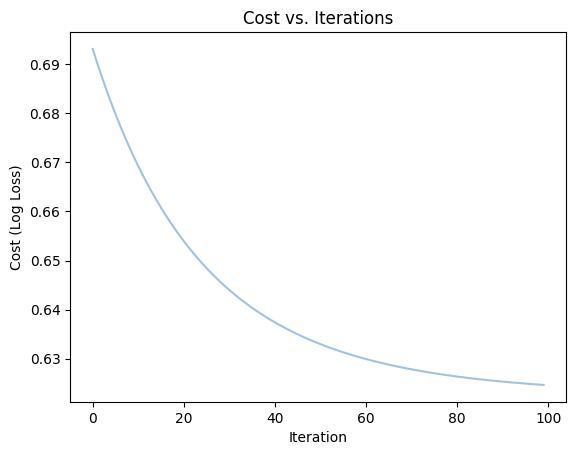

In [3942]:
# plot cost at each iteration
plt.plot(np.arange(num_iters), cost_list, color="#A2C2E0")
plt.title('Cost vs. Iterations')
plt.xlabel('Iteration')
plt.ylabel('Cost (Log Loss)')
plt.show()

The cost decreased steadily over the 100 iterations, which suggests our gradient descent model was successful in minimizing the loss function. The final cost was approximately 0.6246, meaning our model got slightly better at distinguishing between patients with and without heart disease. Although decrease in cost was not very dramatic, we believe the model's performance was reasonable given we haven't added a bias term or regularization yet.

# Task 2 - (4 points)

Cacluate the Accuracy, Precision, Recall and F1 score of your logistic regression implementaion on the testing set. 
Print the results. 

You may use equations shown in lecture/slides/examples.

Calcuate the accuracy, precision, recall and F1 score of your logistic regression implementaion on the testing set. 
Print the results. (**4 points**)


In [3943]:
def predict(weights, X):
    '''
    predict class 0 or 1 using learned logistic regression parameters weights.
    Use threshold value 0.5 to convert probability value to class value
    '''
    p = sigmoid(X.dot(weights)) >= 0.5
    return p.astype(int)

In [3944]:
# get predictions 0 or 1 for each test example
y_pred = predict(weights, X_test)
print('y_pred:\n', y_pred)
print('y_test:\n', y_test)

y_pred:
 [0 1 0 0 0 1 1 0 1 1 0 0 0 1 0 1 1 0 1 0 0 1 1 0 1 0 1 0 0 1 1 1 0 1 1 0 1
 0 1 1 1 1 0 0 0 1 0 0 1 0 1 0 1 1 0 1 1 1 1 1 0]
y_test:
 [0 1 0 1 0 1 0 0 1 0 0 0 0 0 0 1 0 0 1 0 1 1 1 0 0 0 0 1 0 1 1 1 0 1 1 1 1
 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 1 1 1 1 0]


In [3945]:
num_correct = np.sum(y_pred == y_test)
print("Accuracy: ", num_correct/y_test.size)

Accuracy:  0.7377049180327869


In [3946]:
# TP, TN, FP, FN
# add up counts for each case
TP = np.sum((y_pred == 1) & (y_test == 1))
TN = np.sum((y_pred == 0) & (y_test == 0))
FP = np.sum((y_pred == 1) & (y_test == 0))
FN = np.sum((y_pred == 0) & (y_test == 1))

accuracy = (TP + TN) / (TP + TN + FP + FN) # num correct predictions / all predictions
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

# resulting metrics
print(f"Accuracy: {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")
print(f"F1 Score: {f1:.2%}")


Accuracy: 73.77%
Precision: 63.64%
Recall: 84.00%
F1 Score: 72.41%


# Task 3 - (4 points)

Add a y-intercept and repeat the above tasks. Do you see any differences after adding the y-intercept?

(4 points - 2 for code, 1 for cost visualizaiton, 1 for description.)

In [3947]:
# z = X dot w + b
# y_pred = sigmoid(z)

num_iters = 100
learning_rate = 0.1

# add y-intercept term (bias) in w[0]
X_train_intercept = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
X_test_intercept = np.hstack((np.ones((X_test.shape[0], 1)), X_test))
print(X_train_intercept.shape) # 4 cols total

# training the model
cost_list = []
weights_i = np.zeros(X_train_intercept.shape[1])

for i in range(num_iters):

    cost = cost_function(X_train_intercept, y_train, weights_i)
    print(f'Cost for iteration {i + 1}: {cost}')
    cost_list.append(cost)

    grad = gradient(X_train_intercept, y_train, weights_i)
    weights_i = weights_i - learning_rate * grad

(242, 4)
Cost for iteration 1: 0.6931471805599452
Cost for iteration 2: 0.6901632691433192
Cost for iteration 3: 0.6873117917438161
Cost for iteration 4: 0.6845867728031402
Cost for iteration 5: 0.6819824622735725
Cost for iteration 6: 0.6794933350302941
Cost for iteration 7: 0.6771140890118375
Cost for iteration 8: 0.6748396422656289
Cost for iteration 9: 0.672665129064768
Cost for iteration 10: 0.6705858952500816
Cost for iteration 11: 0.6685974929385793
Cost for iteration 12: 0.6666956747262376
Cost for iteration 13: 0.6648763874998654
Cost for iteration 14: 0.6631357659599938
Cost for iteration 15: 0.6614701259444671
Cost for iteration 16: 0.659875957630861
Cost for iteration 17: 0.6583499186851147
Cost for iteration 18: 0.6568888274138963
Cost for iteration 19: 0.6554896559692444
Cost for iteration 20: 0.6541495236459416
Cost for iteration 21: 0.6528656903048556
Cost for iteration 22: 0.6516355499490809
Cost for iteration 23: 0.6504566244740911
Cost for iteration 24: 0.64932655760

In [3948]:
print('Final cost:', cost_list[-1])
print('Final weights:', weights_i)

Final cost: 0.6223511715048263
Final weights: [-0.12027317  0.40218514  0.56956111  0.22020153]


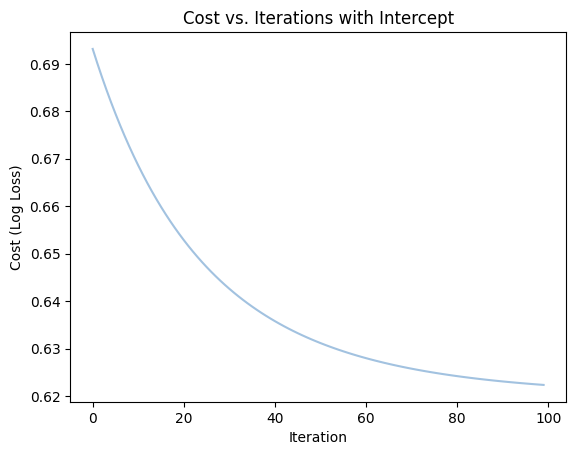

In [3949]:
# plot cost vs. iters
plt.plot(np.arange(num_iters), cost_list, color="#A2C2E0")
plt.title('Cost vs. Iterations with Intercept')
plt.xlabel('Iteration')
plt.ylabel('Cost (Log Loss)')
plt.show()

In [3950]:
y_pred_intercept = predict(weights_i, X_test_intercept)

# TP, TN, FP, FN
# add up counts for each case
TP_i = np.sum((y_pred_intercept == 1) & (y_test == 1))
TN_i = np.sum((y_pred_intercept == 0) & (y_test == 0))
FP_i = np.sum((y_pred_intercept == 1) & (y_test == 0))
FN_i = np.sum((y_pred_intercept == 0) & (y_test == 1))

accuracy_i = (TP_i + TN_i) / (TP_i + TN_i + FP_i + FN_i) # correct predictions / all predictions
precision_i = TP_i / (TP_i + FP_i)
recall_i = TP_i / (TP_i + FN_i)
f1_i = 2 * (precision_i * recall_i) / (precision_i + recall_i)

# resulting metrics
print(f"Accuracy: {accuracy_i:.2%}")
print(f"Precision: {precision_i:.2%}")
print(f"Recall: {recall_i:.2%}")
print(f"F1 Score: {f1_i:.2%}")

Accuracy: 77.05%
Precision: 68.97%
Recall: 80.00%
F1 Score: 74.07%


After adding the y-intercept term to the model, we were able to make the training cost decrease more quickly compared to the previous trial, which suggests a better fit. The Accuracy increased from 73.77% to 77.05%. The Precision increased from 63.64% to 68.97%. The Recall stayed relatively high at 80%, compared to 84% from earlier. The F1-score improved slightly from 72.41% to 74.07%, suggesting both models were balanced in both precision and recall. Overall, adding the bias term improved our model's ability to to fit the data and reduce log loss aka cost.

# Task 4 - Implement the Bold Driver   - (4 points)

Implement the bold driver into your gradient descent implementation, which lets us have a dynamic learning rate. Visualize the costs and print the accuracy/etc. metrics as before. Do not use a y-intercept this time.

Add a stop condition that stop the GD when the cost is not changing more than 0.001 between iterations. 
Describe the results. Did you stop earlier than 100 iterations?
(4 points - 2 for code, 1 for cost visualizaiton, 1 for description.)



In [3951]:
# make copy of the old X_train and X_test for this task
X_train_bold = X_train.copy()
X_test_bold = X_test.copy()


In [3952]:
# running gradient descent with bold driver
num_iters = 100
stop_thresh = 0.001

weights_b = np.zeros(X_train_bold.shape[1])
learning_rate = 0.7
cost_list = []

for i in range(num_iters):

    cost = cost_function(X_train_bold, y_train, weights_b)
    cost_list.append(cost)
    print(f'Cost for iteration {i + 1}: {cost}')

    # check if cost changed, adjust learning rate
    if i > 0:
        cost_change = abs(cost_list[i] - cost_list[i - 1])

        if cost_change < stop_thresh: # change is insignificant, stop early
            print(f'Stop at iteration {i + 1}')
            break
        elif cost < cost_list[i-1]: # cost improved, increase learning_rate
            learning_rate *= 1.1
        else: # cost got worse, halve the learning_rate
            learning_rate /= 2
    
    grad = gradient(X_train_bold, y_train, weights_b)
    weights_b = weights_b - learning_rate * grad

Cost for iteration 1: 0.6931471805599452
Cost for iteration 2: 0.6742143889022829
Cost for iteration 3: 0.659484363422569
Cost for iteration 4: 0.6483474518535929
Cost for iteration 5: 0.6401437147870886
Cost for iteration 6: 0.6342493896901756
Cost for iteration 7: 0.63012045262558
Cost for iteration 8: 0.6273059879899866
Cost for iteration 9: 0.6254451294926326
Cost for iteration 10: 0.6242569584915763
Cost for iteration 11: 0.6235283898557
Stop at iteration 11


In [3953]:
print('Final cost:', cost_list[-1])
print('Final weights:', weights_b)

Final cost: 0.6235283898557
Final weights: [0.42691228 0.6054077  0.23582952]


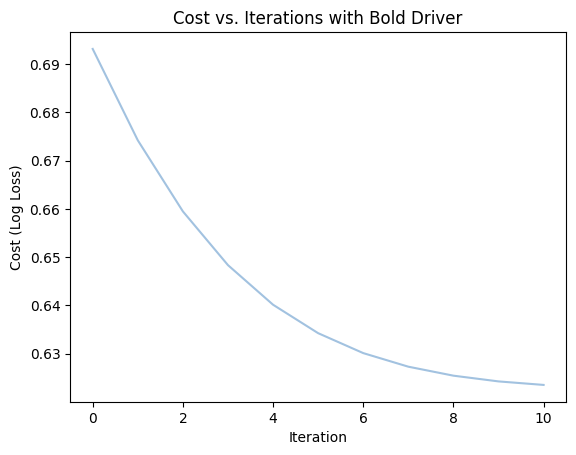

In [3954]:
# plot vs. iters
plt.plot(np.arange(len(cost_list)), cost_list, color="#A2C2E0")
plt.title('Cost vs. Iterations with Bold Driver')
plt.xlabel('Iteration')
plt.ylabel('Cost (Log Loss)')
plt.show()

In [3955]:
y_pred_bold = predict(weights_b, X_test_bold)
# n_correct = np.sum(y_pred_bold == y_test)
# print('Accuracy:', n_correct/y_test.size)

# TP, TN, FP, FN
# add up counts for each case
TP_b = np.sum((y_pred_bold == 1) & (y_test == 1))
TN_b = np.sum((y_pred_bold == 0) & (y_test == 0))
FP_b = np.sum((y_pred_bold == 1) & (y_test == 0))
FN_b = np.sum((y_pred_bold == 0) & (y_test == 1))

accuracy_b = (TP_b + TN_b) / (TP_b + TN_b + FP_b + FN_b)
precision_b = TP_b / (TP_b + FP_b)
recall_b = TP_b / (TP_b + FN_b)
f1_b = 2 * (precision_b * recall_b) / (precision_b + recall_b)

# resulting metrics
print(f"Accuracy: {accuracy_b:.2%}")
print(f"Precision: {precision_b:.2%}")
print(f"Recall: {recall_b:.2%}")
print(f"F1 Score: {f1_b:.2%}")

Accuracy: 73.77%
Precision: 63.64%
Recall: 84.00%
F1 Score: 72.41%


In [ ]:
# just checking!
print(weights)
print(weights_i)
print(weights_b)

[0.40057206 0.56525442 0.21942153]
[-0.12027317  0.40218514  0.56956111  0.22020153]
[0.42691228 0.6054077  0.23582952]


By implementing the bold driver method in our model, we were able to reach convergence by the 11th iteration, well before the max num_iters of 100. Clearly, the bold driver was effective in adjusting the learning rate to accelerate convergence while maintaining stability in the model. The final cost of 0.6235 was lower than the fixed-learning rate model's of 0.6246, suggesting improved optimization.

The evaluation metrics (and weights) for this model were pretty much the same as the fixed-learning run, which means that the decision boundary found by the bold driver model didn't change significantly. However, the added efficiency of having 1/10 the number of iterations remains a plus. Thus, this approach works in reducing training time without sacrificing model performance.

# Task 5 - Implement the L2 norm regularization.  - (4 points)



Modify your Cost and gradient to implement the l2 norm regularization. Repeat the steps taken in prior tasks and describe your result.

 * Use a y-intercept.
 * Do a maximum of 100 iterations as before and report your accuracy, precision, recall and F1 score.
 * Optional: You can stop earlier, if the cost is not changing more than 0.001 between iterations.
 * Optional: You can use the bold driver, if you want. But a bold driver is not required to perform L2 norm regularizaiton.

(4 points - 2 for code, 1 for cost visualizaiton, 1 for description.)

In [3957]:
# Add your code Here! 
# L2 norm reg: prevent overfitting by adding penalty term to loss function

In [3958]:
# update cost func
def cost_function(X, y, weights, lam):
    '''
    compute cost for log reg including L2 regularization
    '''

    m, n = X.shape
    x_dot_weights = X.dot(weights)

    y_pred = sigmoid(x_dot_weights)
    y_pred = np.clip(y_pred, 1e-10, 1 - 1e-10)

    # original log loss
    cost = 1.0 / m * (-y.T.dot(np.log(y_pred)) - (1 - y).T.dot(np.log(1 - y_pred)))
    # add L2 penalty
    penalty = (lam / (2 * m)) * np.sum(weights[1:] ** 2) # don't penalize the bias

    return cost + penalty

In [3959]:
# update gradient fun
def gradient(X, y, weights, lam):
    '''
    compute gradient for LR with L2 regularization
    '''
    m = X.shape[0]
    x_dot_weights = X.dot(weights)
    y_pred = sigmoid(x_dot_weights)

    # regular gradient
    grad = (1 / m) * X.T.dot(y_pred - y)

    # add L2 penalty, excluding bias term
    grad[1:] = grad[1:] + (lam / m) * weights[1:]
    
    return grad

In [3960]:
# train model with loop + grad descent
num_iters = 100
lam = 1
learning_rate = 0.95
cost_list = []

# adding intercept column
X_train_l2 = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
X_test_l2 = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

weights = np.zeros(X_train_l2.shape[1]) # initialize weights

iter = 1
for i in range(num_iters):
    
    cost = cost_function(X_train_l2, y_train, weights, lam)
    print(f'Cost for iteration {iter}: {cost}')
    cost_list.append(cost)
    iter += 1

    grad = gradient(X_train_l2, y_train, weights, lam)
    weights = weights - learning_rate * grad

Cost for iteration 1: 0.6931471805599452
Cost for iteration 2: 0.6675797403567206
Cost for iteration 3: 0.6517867384883991
Cost for iteration 4: 0.6418341054124507
Cost for iteration 5: 0.6354118622945374
Cost for iteration 6: 0.6311750545839153
Cost for iteration 7: 0.6283260851068105
Cost for iteration 8: 0.6263793457922491
Cost for iteration 9: 0.6250312033699577
Cost for iteration 10: 0.6240871410066979
Cost for iteration 11: 0.6234198660341698
Cost for iteration 12: 0.6229445363041737
Cost for iteration 13: 0.6226037086128373
Cost for iteration 14: 0.6223579649467301
Cost for iteration 15: 0.6221799441113469
Cost for iteration 16: 0.6220504664032517
Cost for iteration 17: 0.621955973500627
Cost for iteration 18: 0.6218868113570893
Cost for iteration 19: 0.6218360630753862
Cost for iteration 20: 0.621798746289643
Cost for iteration 21: 0.6217712555396332
Cost for iteration 22: 0.6217509713685406
Cost for iteration 23: 0.6217359841384005
Cost for iteration 24: 0.6217248975539929
Cos

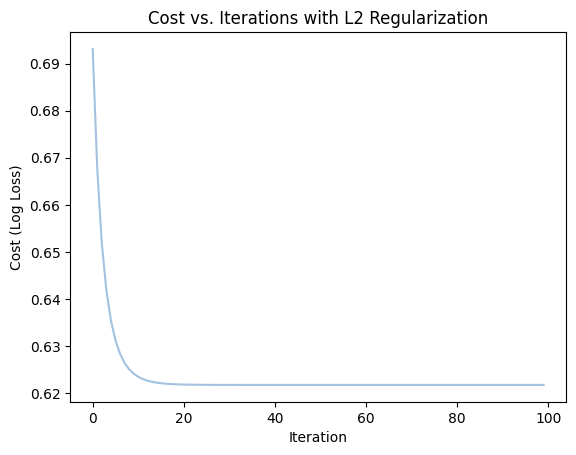

In [3961]:
# plot L2 regularization
# plot cost vs. iters
plt.plot(np.arange(len(cost_list)), cost_list, color="#A2C2E0")
plt.title('Cost vs. Iterations with L2 Regularization')
plt.xlabel('Iteration')
plt.ylabel('Cost (Log Loss)')
plt.show()

In [ ]:
y_pred_L2 = predict(weights, X_test_l2)

# TP, TN, FP, FN
# add up counts for each case
TP_l2 = np.sum((y_pred_L2 == 1) & (y_test == 1))
TN_l2 = np.sum((y_pred_L2 == 0) & (y_test == 0))
FP_l2 = np.sum((y_pred_L2 == 1) & (y_test == 0))
FN_l2 = np.sum((y_pred_L2 == 0) & (y_test == 1))

accuracy_l2 = (TP_l2 + TN_l2) / (TP_l2 + TN_l2 + FP_l2 + FN_l2)
precision_l2 = TP_l2 / (TP_l2 + FP_l2)
recall_l2 = TP_l2 / (TP_l2 + FN_l2)
f1_l2 = 2 * (precision_l2 * recall_l2) / (precision_l2 + recall_l2)

# resulting metrics
print(f"Accuracy: {accuracy_l2:.2%}")
print(f"Precision: {precision_l2:.2%}")
print(f"Recall: {recall_l2:.2%}")
print(f"F1 Score: {f1_l2:.2%}")

Accuracy: 77.05%
Precision: 68.97%
Recall: 80.00%
F1 Score: 72.41%


WRITE DESCRIPTION FOR THIS MODEL HERE

will clean up and adjust some parameters tomorrow!